# Chapter 3: Phase estimation and factorization

Content:
1. The phase estimation problem
2. The phase estimation procedure
    - Low precision warm up
    - Quantum Fourier Transform
    - General procedure
3. Integer factorization by phase estimation
    - Order finding by phase estimation
    - Integer factorization by order finding
4. Implementation on Qiskit

## 1. The phase estimation problem
The spectral theorem is an important fact in linear algebra. It works for unitary matrices.

<b>Theorem</b>:\
Suppose $U$ is a unitary matrix of dimension $N$.There exists an orthonormal basis $|\psi_1\rangle,...,|\psi_N\rangle$ of vectors with complex numbers such that:

$$
\lambda_1 = e^{2\pi i\theta_1},...,\lambda_N = e^{2\pi i\theta_N}
$$

such that:

$$
U = \sum_{k=1}^{N}\lambda_k|\psi_k\rangle\langle\psi_k|
$$

Each vector $|\psi_k\rangle$ is an eigenvector of $U$ that has an eigenvalue $\lambda_k$:

$$
U|\psi_k\rangle = \lambda_k|\psi_k\rangle=e^{2\pi i \theta_k}|\psi_k\rangle
$$

<b>Phase estimation problem</b>:\
In this problem, we have two things:
1. A description of a unitary circuit of n qubits.
2. A quantum state $|\psi\rangle$ of $n$ qubits.

Phase estimation problem:
>Input: A unitary circuit for an n-qubit operation with an n-qubit quantum state.\
>Promise: $|\psi\rangle$ is an eigenvector of $U$.
>Output: An approximation of the number $\theta \in \left[0,1 \right)$ satisfying:

$$
U|\psi\rangle = e^{2\pi i \theta}|\psi\rangle
$$

We can approximate $\theta$  by a fraction:

$$
\theta \approx \frac{y}{2^m}
$$

for $y \in \left\{0,1,..., 2^{m-1} \right\}$. (with modulo 1)

Warm up: using phase kickback

For a $U$ circuit, you can create a controlled-$U$ operator:

<div align="center">
    <img src="./Images/3_1_Controlled_U.png" alt="3_1_Controlled_U" width="600"/>
</div>

Consider the following circuit:

<div align="center">
    <img src="./Images/3_2_Circuit_with_CU.png" alt="3_2_Circuit_with_CU" width="600"/>
</div>

$$|\pi_0\rangle = |\psi\rangle|0\rangle $$
$$|\pi_1\rangle = \frac{1}{\sqrt2}|\psi\rangle|0\rangle+\frac{1}{\sqrt2}|\psi\rangle|1\rangle $$
$$|\pi_2\rangle = \frac{1}{\sqrt2}|\psi\rangle|0\rangle+\frac{1}{\sqrt2}(U|\psi\rangle)|1\rangle $$
$$|\pi_2\rangle = |\psi\rangle\otimes\space(\frac{1}{\sqrt2}|0\rangle+\frac{1}{\sqrt2}e^{2\pi i \theta}|1\rangle) $$
$$|\pi_3\rangle = |\psi\rangle\otimes\space(\frac{1+e^{2\pi i \theta}}{2}|0\rangle+\frac{1-e^{2\pi i \theta}}{2}|1\rangle) $$

By measuring the probabilities of 0 and 1, we obtain:
$$p_0 = \left| \frac{1+e^{2\pi i \theta}}{2} \right| = cos^2(\pi\theta) $$
$$p_1 = \left| \frac{1-e^{2\pi i \theta}}{2} \right| = sin^2(\pi\theta)$$

This is a way to obtain information about the eigenvalues of $U$. We obtain information about the phase.\
Iterating the unitary operation

How can we find out more about $\theta$?\
One possibility is to apply the operation $U$ twice to the circuit.

<div align="center">
    <img src="./Images/3_3_Circuit_with_2CU.png" alt="3_3_Circuit_with_2CU" width="600"/>
</div>

By applying the unitary matrix twice, we obtain the circuit in $U^2$. In this case, the applied phase is $2\theta$, and we obtain the desired phase by dividing the phase by $2$.

Two control qubits:\
Let us consider a circuit with one unitary operation controlled by one qubit and two other unitary operations controlled by another qubit.

<div align="center">
    <img src="./Images/3_4_2control_qubits_circuit.png" alt="3_4_2control_qubits_circuit" width="600"/>
</div>

$$|\pi_1\rangle = |\psi\rangle \otimes \space  \sum_{a_0=0}^{1}\sum_{a_1=0}^{1}|a_1a_0\rangle $$
$$|\pi_2\rangle = |\psi\rangle \otimes \space \frac{1}{2} \sum_{a_0=0}^{1}\sum_{a_1=0}^{1}e^{2\pi ia_0\theta}|a_1a_0\rangle $$
$$|\pi_3\rangle = |\psi\rangle \otimes \space \frac{1}{2} \sum_{a_0=0}^{1}\sum_{a_1=0}^{1}e^{2\pi i(2a_1 +a_0)\theta}|a_1a_0\rangle $$

Let $x = 2a_1+a_0$. The factor $2$ of $a_1$ comes from applying the circuit twice to a single qubit.  We then have:

$$
|\pi_3\rangle = |\psi\rangle \otimes \space \frac{1}{2} \sum_{x=0}^{3}e^{2\pi ix\theta}|a_1a_0\rangle \\
$$

What can we know about $\theta$? We can assume that we have a promise that $\theta = \frac{y}{4}$ for $y \in \left\{ 0,1,2,3\right\}$. Can we know which one it is? 

Let's define a $2$-qubit state for each probability.

$$
|\phi_y\rangle =  \frac{1}{2} \sum_{x=0}^{3}e^{2\pi i\frac{xy}{4}}|a_1a_0\rangle $$
$$|\phi_0\rangle = \frac{1}{2}|0\rangle + \frac{1}{2}|1\rangle + \frac{1}{2}|2\rangle + \frac{1}{2}|3\rangle $$
$$|\phi_1\rangle = \frac{1}{2}|0\rangle + \frac{i}{2}|1\rangle - \frac{1}{2}|2\rangle - \frac{i}{2}|3\rangle $$
$$|\phi_2\rangle = \frac{1}{2}|0\rangle - \frac{1}{2}|1\rangle + \frac{1}{2}|2\rangle - \frac{1}{2}|3\rangle $$
$$|\phi_3\rangle = \frac{1}{2}|0\rangle - \frac{i}{2}|1\rangle - \frac{1}{2}|2\rangle + \frac{i}{2}|3\rangle
$$

These four vectors are orthonormal; they perfectly describe a projection of measurements. 

$$
\left\{|\phi_0\rangle\langle\phi_0|,|\phi_1\rangle\langle\phi_1|,|\phi_2\rangle\langle\phi_2|,|\phi_3\rangle\langle\phi_3| \right\}
$$

The unitary matrix whose columns are $|\phi_0\rangle, |\phi_1\rangle, |\phi_2\rangle, |\phi_3\rangle$ has this action:

 

$$
V|y\rangle = |\phi_y\rangle,  \space\space \forall y \in \left\{ 0,1,2,3\right\}
$$

inverse of $V$ in the standard basis:
$$V^\dagger|\phi_y\rangle = |y\rangle, \space\space \forall y \in \left\{ 0,1,2,3\right\}$$

The resulting matrix corresponds to a discrete Fourier transform matrix (dimension 4):

$$
V = \frac{1}{2}\left( \begin{matrix}                   1& 1 & 1 & 1 \\ 1& i & -1 & -i \\ 1& -1 & 1 & -1 \\ 1 & -i & -1 & i \end{matrix}\right)
$$

This type of matrix is called a quantum Fourier transform. The complete circuit for learning about $y \in \left\{ 0,1,2,3\right\}$.
<div align="center">
    <img src="./Images/3_5_2control_qubits_circuit_QFTdag.png" alt="3_5_2control_qubits_circuit_QFTdag" width="600"/>
</div>

The probability of output when the circuit is turned on:

<div align="center">
    <img src="./Images/3_6_probability_output.png" alt="3_6_probability_output" width="600"/>
</div>

According to the graph, the probability of obtaining the most accurate measurement of $x$ is above $40$%. Indeed, for values of $\theta = 3/8$, we arrive at the trough or the superposition of two curves, which corresponds to the minimum probability of measuring the information.

Quantum Fourier Transform:
The quantum Fourier transform is defined for every positive integer $N$:

$$QFT_N = \frac{1}{\sqrt{N}}\sum_{x=0}^{N-1}\sum_{y=0}^{N-1}e^{\frac{2\pi ixy}{N}} |x\rangle\langle y| $$
$$QFT_N|y\rangle = \frac{1}{\sqrt{N}}\sum_{x=0}^{N-1}e^{\frac{2\pi ixy}{N}}|x\rangle$$

Practical notation:

$$w_N = e^{\frac{2\pi i}{N}}=cos(\frac{2\pi}{N})+i*sin(\frac{2\pi}{N})$$

The implementation of the quantum Fourier transform uses controlled-phase gates:
<div align="center">
    <img src="./Images/3_7_CPhase_gate.png" alt="3_7_CPhase_gate" width="600"/>
</div>

The implementation is recursive in nature. For example, here we have a $32$-bit QTF circuit:

<div align="center">
    <img src="./Images/3_8_example_QFT_32bit.png" alt="3_8_example_QFT_32bit" width="600"/>
</div>

<b>Cost analysis</b>:
Let $s_m$ be the number of gates needed for m qubits.

- For $m = 1$, a Hadamard gate is required
- For $m \geq 2$, the following gates are required:
- $s_{m-1}$ gates for QFT on $m-1$ qubits
- $m-1$ controlled phase gates
- $m-1$ swap gates
- 1 Hadamard gate

$$
s_m = \begin{equation}
    \left\{ 
        \begin{array}{cc}
                1 & \text{if } m=1 \\ s_{m-1}+2m-1 & \text{if } m\geq 2 
        \end{array}
    \right .
\end{equation}
$$

By recurrence, we have a relationship of the form:

$$
s_m = \sum_{k=1}^{m}(2k-1)=m^2
$$

Note:

The number of door swaps can be reduced.The approximation of $QFT_{2^{m}}$ can be done at a lower depth.

General procedure for phase estimation:


Warning:

If each $U^k$ operation is used by repeating a controlled operation $U$ k times, increasing the number of control qubits $m$ comes at a high cost.

<div align="center">
    <img src="./Images/3_9_Phase_estimation_circuit.png" alt="3_9_Phase_estimation_circuit" width="600"/>
</div>

expression of the system upstream of the measurement:
$$ |\pi\rangle = |\psi\rangle\otimes\frac{1}{2^m}\sum_{u=0}^{2^m-1} \sum_{x=0}^{2^m-1}e^{2\pi ix(\theta-y/2^m)}|y\rangle$$

Probaility to measure $y$:

$$ p_y=\left|\frac{1}{2^m}\sum_{x=0}^{2^m-1}e^{2\pi ix(\theta-y/2^m)}\right|^2$$

The more qubits there are, the greater the precision.

<u>Best approximation</u>:
>Let's assume that $y/2^m$ is the best approximation of $\theta$:\
>$$
\left| \theta-\frac{y}{2^m} \right| \le 2^{-(m-1)}
$$
>Then the probability of measuring $y$ is highly relative:
>$$
p_y \ge \frac{4}{\pi^2} \approx 0.405
$$

<u>Worst approximation</u>:
>Suppose there is a best approximation of $\theta$ between  $y/2^m$ and $\theta$ : 
>$$
\left| \theta-\frac{y}{2^m} \right| \ge 2^{-m}
$$
>Then the probability of measuring $y$ is very low:\
>$$
p_y \le \frac{1}{4}
$$
>To obtain an approximation of $y/2^m$, it is similar to satisfying
>$$
\left| \theta-\frac{y}{2^m} \right| \lt 2^{-m}
$$

We can run the estimation procedure using m qubits several times and take $y$ to be the mode of the output. The eigenvector is not modified by the procedure and can be reused as many times as necessary.

## 3. Integer factorization by phase estimation

<b>The order Finding problem</b>:\
For each positive integer N, we define:

$$
\mathbb{Z} = \left\{ 0,1,...N-1\right\}
$$

We define the modulo $N$ on $\mathbb{Z}_N$

We say that the elements $a \in \mathbb{Z}_{N}$ are special when $gcd(a,N) = 1$, i.e.: 

For any element $a \in \mathbb{Z}_{N}^{*} = \left\{ a \in \mathbb{Z}_{N}: gcd(a,N)=1 \right\}$

Fact:

For any  $a \in \mathbb{Z}_{N}^*$, there exists a positive integer $k$ such that $a^k=1$. The smallest $k$ is called the order of a in  $\mathbb{Z}_{N}^*$.

<b> order Finding problem</b>:
>Input: Positive integers a and N with gcd(a,N) = 1\
>Output: The smallest positive integer r such that $a^r = 1( \text{mod N})$

No classical algorithm can solve this problem.

To connect the problem with phase estimation, we will consider a set $\mathbb{Z}_{N}$.

For an element $a \in \mathbb{Z}_{N}^*$, we define the following operation:

$$
M_a|x\rangle = |ax\rangle \space\space(\forall x \in \mathbb{Z}_N)
$$

This is a unitary operation, because $gcd(a,N) = 1$.

The main idea:\
The eigenvalues of $M_a$ are strongly connected to the order of $a$. By approximating certain eigenvalues with sufficient precision using phase estimation, we are able to calculate the order.\
Here is an eigenvector of $M_a$:

$$
|\psi_0\rangle = \frac{|1\rangle+|a\rangle+...+|a^{r-1}\rangle}{\sqrt{r}}
$$

$r$ is the order of $a$. The associated eigenvalue is $1$:

$$
M_a|\psi_0\rangle = \frac{|a\rangle+|a^2\rangle+...+|a^r\rangle}{\sqrt{r}} = \frac {|a\rangle+|a^2\rangle+...+|a^{r-1}\rangle+|1\rangle}{\sqrt{r}} = |\psi_0\rangle
$$

To identify more eigenvectors, we can use the notation:

$$
\omega_r = e^{2\pi i/r}
$$

Here is another eigenvector of $M_a$:

$$
|\psi_1\rangle = \frac{|1\rangle+\omega_r^{-1}|a\rangle+...+\omega_r^{-(r-1)}|a^{r-1}\rangle}{\sqrt{r}}
$$

by calculation:

$$
M_a|\psi_1\rangle = \omega_r|\psi_1\rangle
$$

in general,
$$M_a|\psi_j\rangle = \omega_r^j|\psi_j\rangle$$

Suppose that $|\psi_1\rangle$ is in a quantum state. We can learn about $r$ by performing the following operations:

1. Use phase estimation on the state $|\psi_1\rangle$ and a quantum circuit implemented with $M_a$.
2. The output $2^m/y$ is rounded to the nearest integer
    
    $$
    \text{round}(\frac{2^m}{y})=\lt \left\lfloor \frac{2^m}{y} + \frac{1}{2} \right\rfloor
    $$
    

How much precision is needed to correctly determine $r$? 

$$
\left| \frac{2^m}{y} - \frac{1}{r} \right| \le \frac{1}{2N^2} \Rightarrow \text{round}(\frac{2^m}{y})=r
$$

By choosing $m=2lg(N)+1$ in phase estimation, a good estimate can be obtained.

Suppose we have a vector $|\psi_j\rangle$ in a quantum state for a random choice of $j \in \left\{0,...,r-1 \right\}$. We can hope to learn about $j/r$ in the following way:

1. Perform phase estimation on the state $|\psi_j\rangle$ and a quantum circuit implementing $M_a$. The output of the circuit gives an approximation of $y/2^m \approx j/r$
2. Among the fractions $u/v$ whose lowest term satisfies $u,v \in \left\{0,..., r-1 \right\}$ and $v \neq 0$, the output that is closest to $y/2^m$. This can be done efficiently using the continued fraction algorithm.

How much precision is needed to correctly determine $u/v = j/r$?

$$
\left| \frac{2^m}{y} - \frac{1}{r} \right| \le \frac{1}{2N^2} \Rightarrow \frac{u}{v} = \frac{j}{r}
$$

Choosing $m=lg(N)+1$ for the phase estimation allows such an approximation.

We may be unlucky: $j$ has a common factor with $r$. 

In this case, if we draw samples independently for  $j \in \left\{ 0,1,...r-1\right\}$ chosen uniformly, we can recover $r$ with a high probability by calculating the least common multiple of the observed values of $v$.

<u>Implementation</u>:

Cost of the function $n=lg(N)$

- Cost for each controlled unitary 
>    $M_a$ has a cost of $O(n^2)$   
>    We need to implement $M_a^k$ for each $k = 1,2,4,8,...,2^{m-1}$. Each $M_a^k$ can be implemented as follows:   
>>    - Calculate $b=a^k \space (\text{mod }N)$
>>   - Use a circuit for $M_b$
>    The cost of implementing $M_b = M_a^k$ is $O(n^2)$
- $m$ Hadamard gates: $O(n)$
- $m$ unitary control operations: $O(n^3)$
- Quantum Fourier Transform: $O(n^2)$

Total cost: $O(n^3)$

Reminder: we must obtain one of the eigenvectors $\psi_0, \psi_1, ..., \psi_{r-1}$.

Solution: replace the eigenvector $\psi$ with $|1\rangle$

This works because: 

$$
|1\rangle = \frac{|\psi_0\rangle+|\psi_1\rangle+...+|\psi_{r-1}\rangle}{\sqrt{r}} 
$$

The output is the same if we choose $j \in \left\{0,...,r-1 \right\}$ uniformly and use $|\psi\rangle = |\psi_j\rangle$

<b>Factorization through order finding</b>:

The following method allows us to find a factor of $N$ with a probability of at least $1/2$, to predict that $N$ is odd and not prime.

Factor finding method:

1. Choose  $a \in \left\{2,...,N-1 \right\}$ randomly.
2. Calculate $d = gcd(a,N)$ . If $d\geq 2$ then the output is $d$ and stop.
3. Calculate the order $r$ of a modulo $N$
4. If $r$ is even, then calculate $d=gcd(a^{1/2}-1,N).$ If $d\geq 2$, then $d$ is the output and stop
5. If this step is reached, the method has failed.

Main Idea:

>1. By the definition of order, we know that $a^r=1 (mod \space N)$ 
>$$
a^r=1 (mod\space N) \Leftrightarrow  \text{N divides } a^r-1
$$

>2. If $r$ is even, then:
>$$
a^r-1 = (a^{1/2}+1)(a^{1/2}-1)
$$

Every prime number that divides $N$ must therefore divide $(a^{1/2}+1)$ or $(a^{1/2}-1)$. For a random number $a$, at least one prime number of $N$ divides $(a^{1/2}-1)$.

## 4. Implementation on Qiskit

In [3]:
from qiskit.quantum_info import Statevector
from qiskit.quantum_info.operators import Operator
from qiskit.visualization import plot_histogram
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

from math import pi, cos, sin

In [2]:
psi1 = Statevector([cos(pi / 8), sin(pi / 8)])
psi2 = Statevector([cos(5 * pi / 8), sin(5 * pi / 8)])

# When given a Statevector input, the Operator function returns the outer
# product of that state vector with itself — or, in other words, the
# product of the vector times its conjugate transpose.

H = Operator(psi1) - Operator(psi2)
display(H.draw("latex"))

<IPython.core.display.Latex object>

### Using the phase kickback

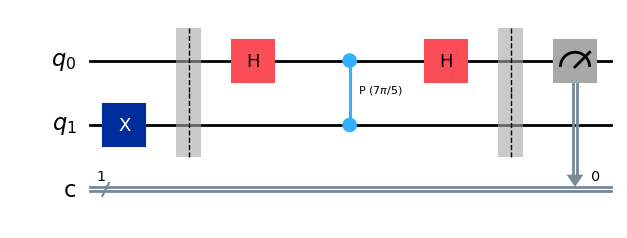

In [4]:
theta = 0.7  # Can be changed to any value between 0 and 1
qc = QuantumCircuit(2, 1)

# Prepare the eigenvector, which is the |1> state
qc.x(1)
qc.barrier()

# Implement the estimation procedure
qc.h(0)
qc.cp(2 * pi * theta, 0, 1)
qc.h(0)
qc.barrier()

# Perform the final measurement
qc.measure(0, 0)

# Draw the circuit
display(qc.draw(output="mpl"))


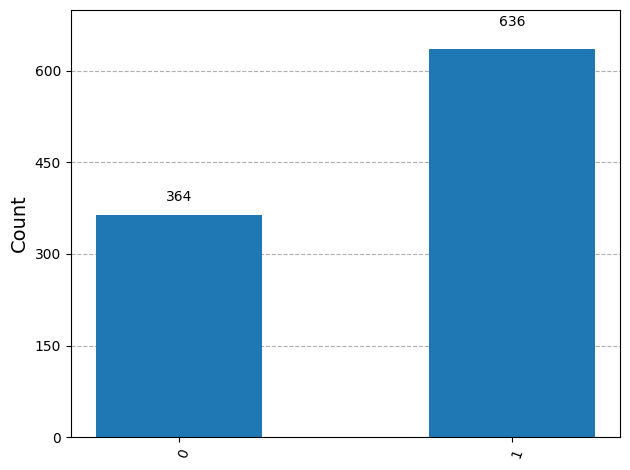

In [5]:
result = AerSimulator().run(qc, shots = 1000).result()
stat = result.get_counts()
plot_histogram(stat)

In [6]:
print(f"cos(pi * {theta})^2 * nb_shot = {cos(pi * theta) ** 2*1000:.4f}")
print(f"sin(pi * {theta})^2 * nb_shot = {sin(pi * theta) ** 2*1000:.4f}")

cos(pi * 0.7)^2 * nb_shot = 345.4915
sin(pi * 0.7)^2 * nb_shot = 654.5085


### Quantum Fourier Transform (dim 4)


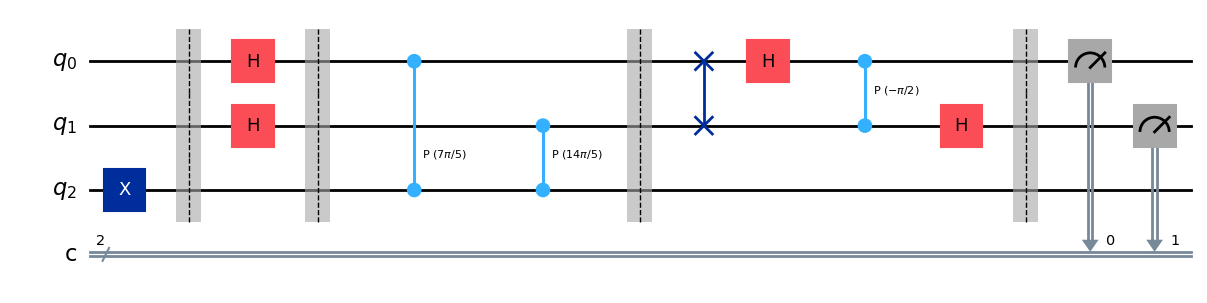

In [7]:
thetat = 0.7
qc = QuantumCircuit(3,2)

# prepare the eigenvector
qc.x(2)
qc.barrier()

# the initla hadamard gates
qc.h(0)
qc.h(1)
qc.barrier()

# the controlled unitary gates
qc.cp(2*pi*theta, 0, 2)
qc.cp(2*pi*(2*theta), 1, 2)
qc.barrier()

# implementation of the inverse of the two-qubit QFT
qc.swap(0,1)
qc.h(0)
qc.cp(-pi/2,0,1)
qc.h(1)
qc.barrier()

qc.measure([0,1],[0,1])

display(qc.draw("mpl"))

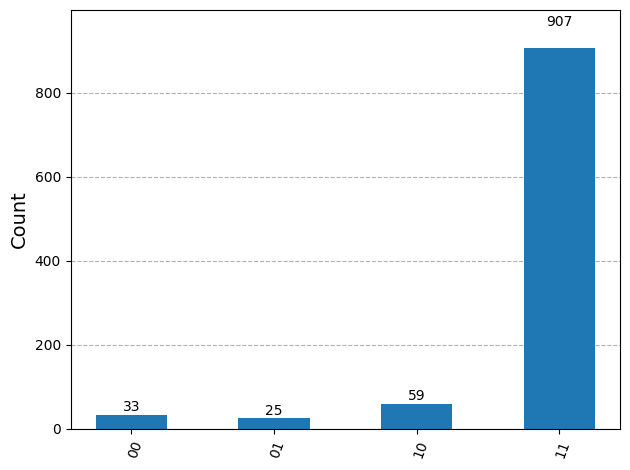

In [8]:
result = AerSimulator().run(qc).result()
stat = result.get_counts()
display(plot_histogram(stat))


In [10]:
qc = QuantumCircuit(3)

# prepare the eigenvector
qc.x(2)
qc.barrier()

# the initla hadamard gates
qc.h(0)
qc.h(1)
qc.barrier()

# the controlled unitary gates
qc.cp(2*pi*theta, 0, 2)
qc.cp(2*pi*(2*theta), 1, 2)
qc.barrier()

# implementation of the inverse of the two-qubit QFT
qc.swap(0,1)
qc.h(0)
qc.cp(-pi/2,0,1)
qc.h(1)
qc.barrier()
sv = Statevector.from_instruction(qc)
sv.draw("latex")

<IPython.core.display.Latex object>

### Quantum Fourier Transform

In [13]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFTGate

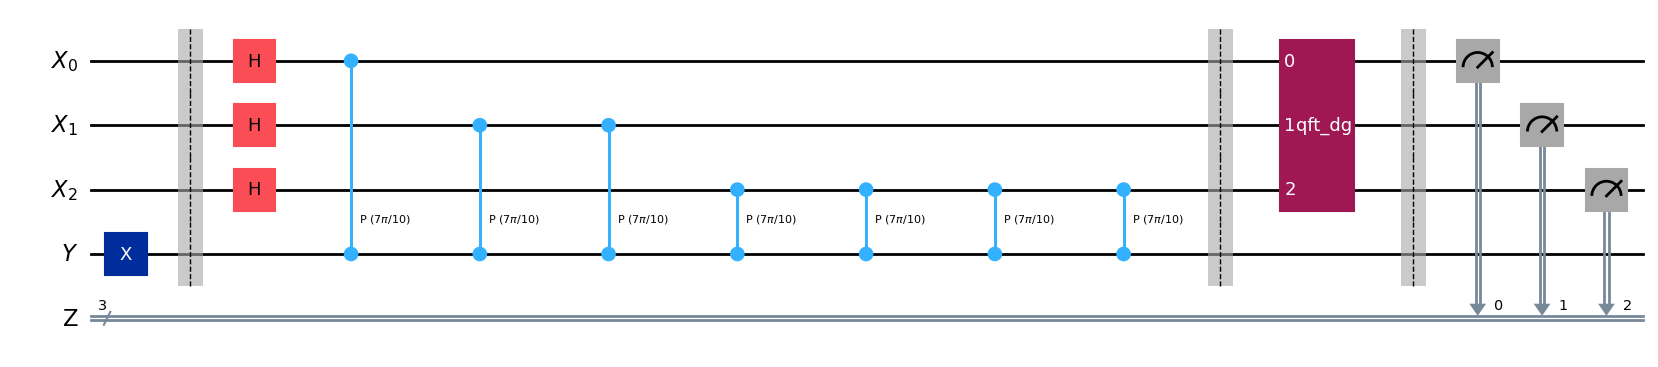

In [15]:
theta = 0.35
m = 3# nombr de qubits de control

control = QuantumRegister(m, name = "X")
target = QuantumRegister(1, name = "Y")
output = ClassicalRegister(m, name="Z")
qc = QuantumCircuit(control, target, output)

# prepare the eigenvector
qc.x(target)
qc.barrier()

# perform phase estimation
for index, qubit in enumerate(control):
    qc.h(index)
    for _ in range(2**index):
        qc.cp(2*pi*theta, qubit, target)
qc.barrier()

# perform the inverse quantum Fourier Transform
qc.compose(
    QFTGate(m).inverse(),
    inplace = True
)
qc.barrier()

qc.measure(range(m), range(m))
qc.draw("mpl")

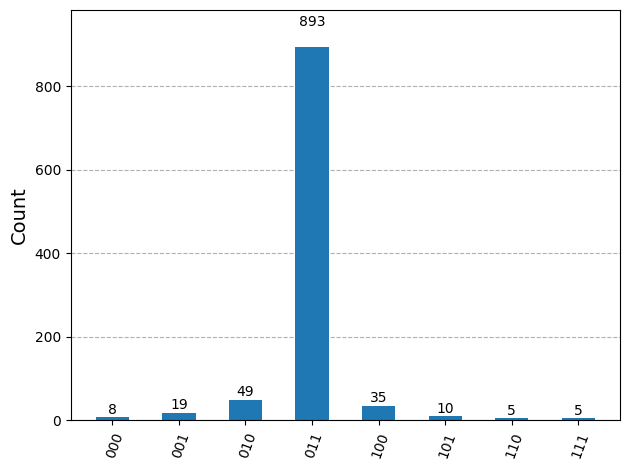

In [17]:
result = AerSimulator().run(qc.decompose()).result()
stat = result.get_counts()
plot_histogram(stat)

In [18]:
most_probable = int(max(stat, key=stat.get),2)

print(f"Most probable output: {most_probable}")
print(f"Estimated theta: {most_probable/2**m}")

Most probable output: 3
Estimated theta: 0.375


### Shor Algorithm

In [19]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info.operators import Operator
from qiskit.circuit.library import UnitaryGate
from qiskit.circuit.library import QFTGate
from qiskit_aer import AerSimulator
import numpy as np
from math import gcd, floor, log
from fractions import Fraction
import random

In [24]:
def mod_mult_gate(b,N):
    # M_b function for an element of B in Zn
    if gcd(b,N)>1:
        print(f"Error: gcd({b},{N}) > 1")
    else:
        n = floor(log(N-1,2))+1
        U = np.full((2**n, 2**n),0)
        for x in range(N): U[b*x % N][x] = 1
        for x in range(N, 2**n): U[x][x] = 1
        G = UnitaryGate(U)
        G.name = f"M_{b}"
        return G

def order_finding_circuit(a,N):
    # Create the circuit for order finding
    if gcd(a,N)>1:
        print(f"Error: gcd({a},{N}) > 1")
    else:
        n = floor(log(N-1,2))+1
        m = 2*n

        control  =QuantumRegister(m, name = "X")
        target = QuantumRegister(n, name="Y")
        output = ClassicalRegister(m, name="Z")
        circuit = QuantumCircuit(control, target, output)

        # initialize the target register to the state \1>
        circuit.x(m)

        # Add hadamard gates and controlled versions of the multiplications gates
        for k, qubit in enumerate(control):
            circuit.h(k)
            b = pow(a,2**k,N)
            circuit.compose(
                mod_mult_gate(b,N).control(),
            qubits = [qubit] + list(target), inplace = True)

        # apply the inverse QFT to the control register
        circuit.compose(
            QFTGate(m).inverse(), 
            qubits = control, inplace = True)

        #measure the control register
        circuit.measure(control, output)
        return circuit

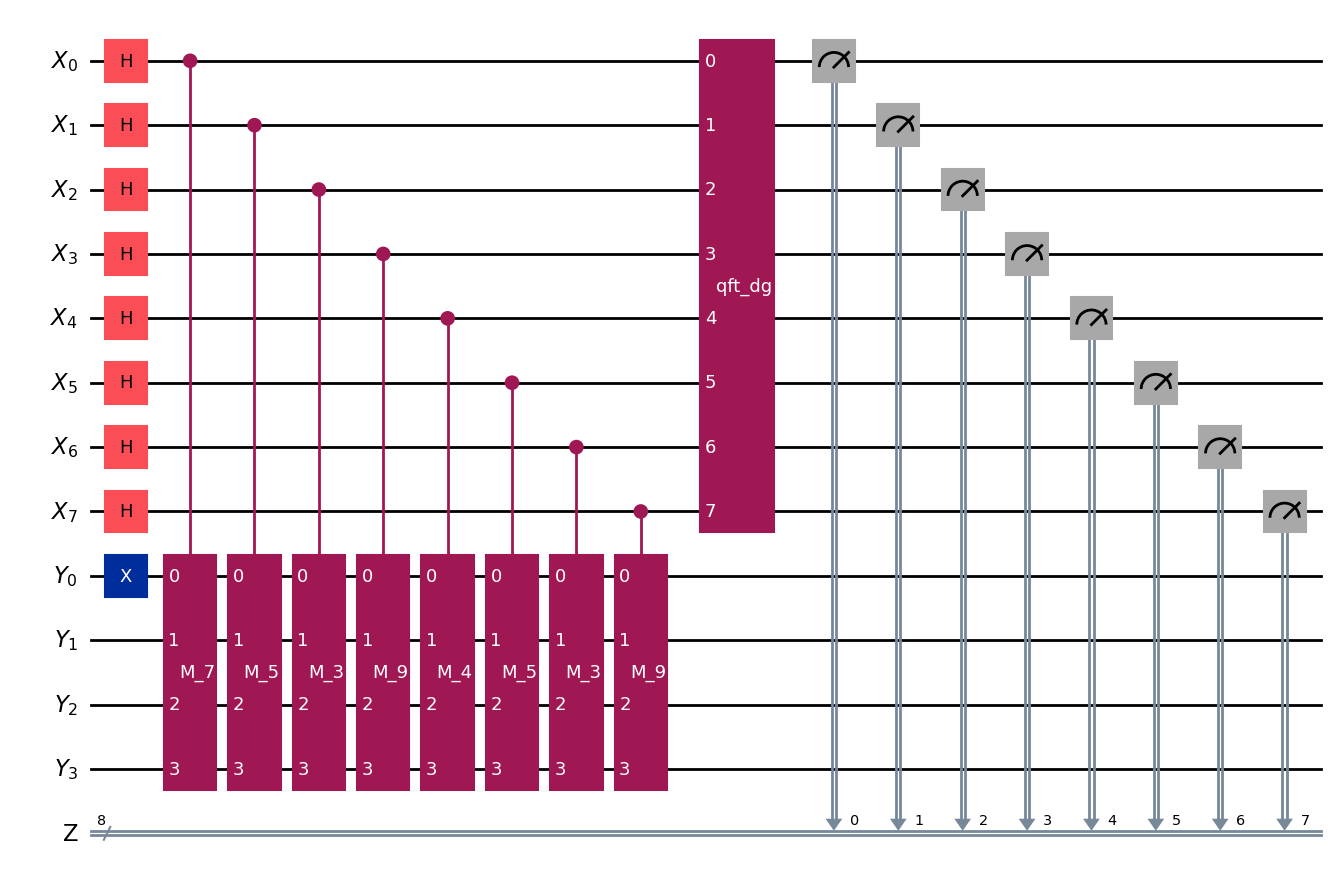

In [25]:
# Example
order_finding_circuit(7,11).draw("mpl")

In [26]:
# to run the circuit on simulator
def find_order(a,N):
    if gcd(a,N)>1:
        print(f"Error: gcd({a},{N}) > 1")
    else:
        n = floor(log(N-1,2))+1
        m = 2*n
        circuit = order_finding_circuit(a,N)
        transpiled_circuit = transpile(circuit, AerSimulator())

        while True:
            result = AerSimulator().run(transpiled_circuit, shots = 1, memory = True).result()
            y = int(result.get_memory()[0],2)
            r = Fraction(y/2**m).limit_denominator(N).denominator
            if pow(a,r,N)==1 : break
        return r

In [27]:
N = 11
a = 7
print(f"The order of {a} modulo {N} is {find_order(a,N)}.")

The order of 7 modulo 11 is 10.


In [ ]:
# To run the circuit on real device
def find_order(a,N):
    if gcd(a,N)>1:
        print(f"Error: gcd({a},{N}) > 1")
    else:
        n = floor(log(N-1,2)) + 1
        m = 2*n
        circuit = order_finding_circuit(a,N)
        transpiled_circuit = transpile(circuit,AerSimulator())

        service = QiskitRuntimeService()
        backend = service.least_busy(min_num_qubits=127)
        pass_manager = generate_preset_pass_manager(optimization_level=3, backend=backend, seed_transpiler=1234) #seed_trasnpiler avec un entier pour assurer la reproductibilité

        isa_circuit = pass_manager.run(transpiled_circuit)

            y = int(result.get_memory()[0],2)
            r = Fraction(y/2**m).limit_denominator(N).denominator
            if pow(a,r,N)==1: break
        return r